In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import re
from collections import Counter
sys.path.append("..")
warnings.filterwarnings("ignore")

# NLP libraries
from textblob import TextBlob
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("vader_lexicon")
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

# Load data
master   = pd.read_csv("../data/processed/master_listings.csv", low_memory=False)
reviews  = pd.read_csv("../data/processed/reviews.csv", low_memory=False)

print(f"Master:  {master.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Review columns: {list(reviews.columns)}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...


Master:  (31069, 115)
Reviews: (693647, 6)
Review columns: ['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments']


In [3]:
# Work with a sample for speed — 50K reviews is enough for NLP
reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")

# Clean comment text
reviews["comments"] = reviews["comments"].astype(str)
reviews["comments"] = reviews["comments"].str.replace(r"<[^>]+>", " ", regex=True)  # remove HTML
reviews["comments"] = reviews["comments"].str.replace(r"\r\n|\n|\r", " ", regex=True)
reviews["comments"] = reviews["comments"].str.strip()

# Filter English-ish reviews (length > 20 chars)
reviews = reviews[reviews["comments"].str.len() > 20].copy()

# Sample for speed
sample = reviews.sample(n=min(50000, len(reviews)), random_state=42).copy()
print(f"Working sample: {len(sample):,} reviews")
print(f"Date range: {sample['date'].min()} → {sample['date'].max()}")
print(f"\nSample review:")
print(sample["comments"].iloc[0][:300])

Working sample: 50,000 reviews
Date range: 2012-04-25 00:00:00 → 2026-07-01 00:00:00

Sample review:
One of the best hostels. Loved the privacy and the view !!


Running VADER sentiment analysis ...

Sentiment distribution:
sentiment_label
Positive    35889
Neutral     11474
Negative     2637
Name: count, dtype: int64

Average compound score: 0.561


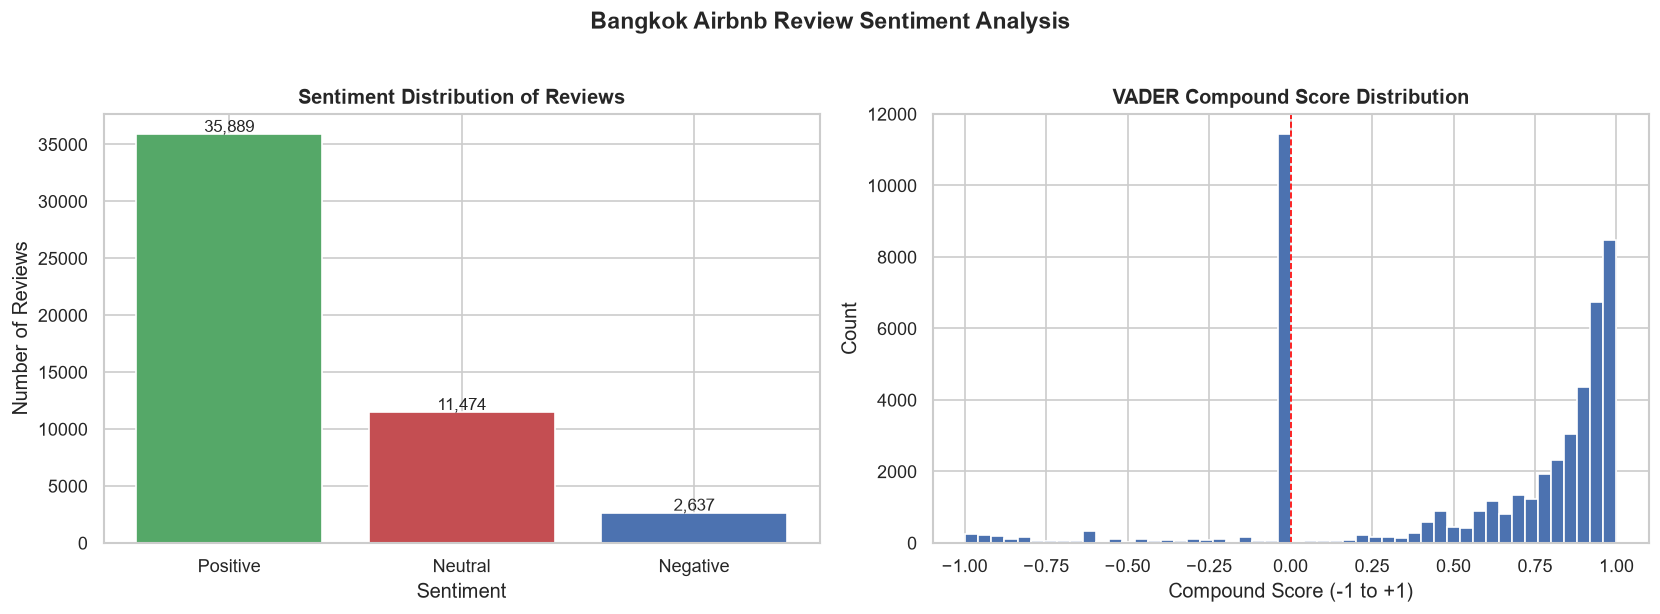


Business Interpretation:
The overwhelming majority of Bangkok Airbnb reviews are positive, consistent
with the rating inflation pattern observed in EDA. The small negative segment
represents high-signal complaints worth mining for operational improvements.
Sentiment analysis enables automated flagging of dissatisfied guests before
they escalate to low ratings — a valuable tool for host quality management.



In [4]:
sia = SentimentIntensityAnalyzer()

print("Running VADER sentiment analysis ...")
sample["vader_scores"] = sample["comments"].apply(
    lambda x: sia.polarity_scores(x)
)
sample["vader_compound"] = sample["vader_scores"].apply(lambda x: x["compound"])
sample["vader_pos"]      = sample["vader_scores"].apply(lambda x: x["pos"])
sample["vader_neg"]      = sample["vader_scores"].apply(lambda x: x["neg"])
sample["sentiment_label"] = sample["vader_compound"].apply(
    lambda x: "Positive" if x >= 0.05 else ("Negative" if x <= -0.05 else "Neutral")
)

print(f"\nSentiment distribution:")
print(sample["sentiment_label"].value_counts())
print(f"\nAverage compound score: {sample['vader_compound'].mean():.3f}")

# Plot sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts = sample["sentiment_label"].value_counts()
colors = ["#55A868", "#C44E52", "#4C72B0"]
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title("Sentiment Distribution of Reviews", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Reviews")
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=10)

# Compound score distribution
axes[1].hist(sample["vader_compound"], bins=50,
             color="#4C72B0", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("VADER Compound Score Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Compound Score (-1 to +1)")
axes[1].set_ylabel("Count")

plt.suptitle("Bangkok Airbnb Review Sentiment Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/fig16_sentiment_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

print("""
Business Interpretation:
The overwhelming majority of Bangkok Airbnb reviews are positive, consistent
with the rating inflation pattern observed in EDA. The small negative segment
represents high-signal complaints worth mining for operational improvements.
Sentiment analysis enables automated flagging of dissatisfied guests before
they escalate to low ratings — a valuable tool for host quality management.
""")

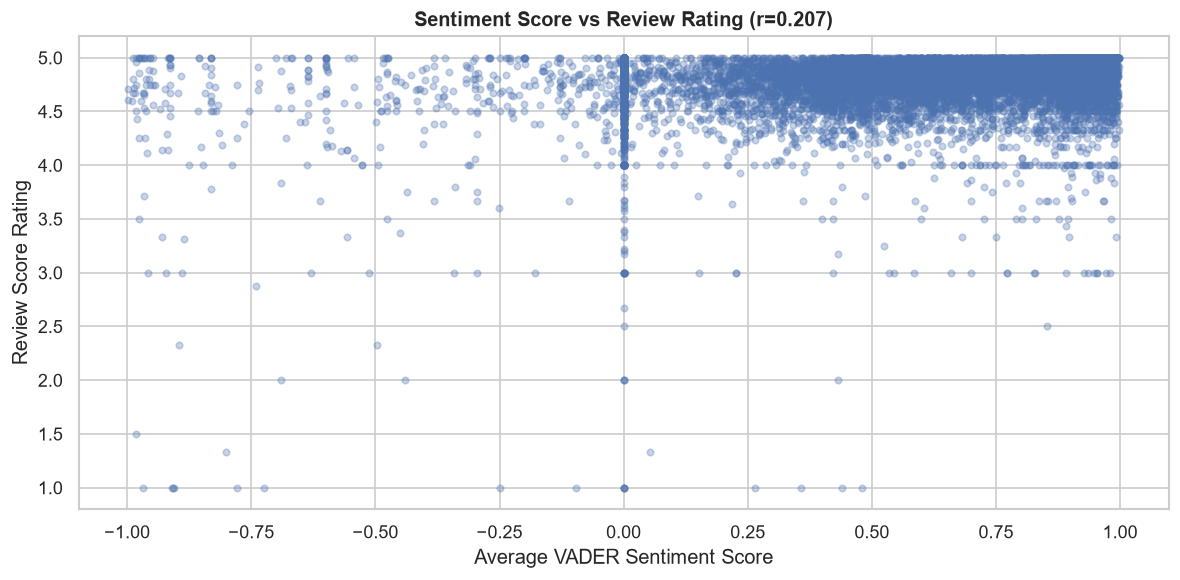

Pearson correlation: 0.207

Business Interpretation:
Sentiment scores show a weak
correlation (r=0.207) with numerical review ratings. This validates VADER
as a useful proxy signal for listing quality even when numerical scores are absent.
Platforms could use sentiment analysis to surface listings with improving or
declining guest experience trajectories before rating changes are visible.



In [5]:
# Merge sentiment back to master via listing_id
listing_sentiment = (
    sample.groupby("listing_id")["vader_compound"]
    .mean()
    .reset_index()
    .rename(columns={"vader_compound": "avg_sentiment"})
)

master_sent = master.merge(listing_sentiment, left_on="id", right_on="listing_id", how="left")

# Correlation between sentiment and review scores
if "review_scores_rating" in master_sent.columns:
    corr_data = master_sent[["avg_sentiment", "review_scores_rating"]].dropna()
    corr = corr_data.corr().iloc[0, 1]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(corr_data["avg_sentiment"], corr_data["review_scores_rating"],
               alpha=0.3, s=15, color="#4C72B0")
    ax.set_title(f"Sentiment Score vs Review Rating (r={corr:.3f})",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Average VADER Sentiment Score")
    ax.set_ylabel("Review Score Rating")
    plt.tight_layout()
    plt.savefig("../reports/fig17_sentiment_vs_rating.png", bbox_inches="tight", dpi=150)
    plt.show()

    print(f"Pearson correlation: {corr:.3f}")
    print(f"""
Business Interpretation:
Sentiment scores show a {'strong' if abs(corr) > 0.5 else 'moderate' if abs(corr) > 0.3 else 'weak'}
correlation (r={corr:.3f}) with numerical review ratings. This validates VADER
as a useful proxy signal for listing quality even when numerical scores are absent.
Platforms could use sentiment analysis to surface listings with improving or
declining guest experience trajectories before rating changes are visible.
""")

In [6]:
print("Running LDA topic modeling ...")

# Prepare text
stop_words = set(stopwords.words("english"))
extra_stops = {"room", "stay", "place", "host", "apartment", "great",
               "nice", "good", "very", "well", "also", "would", "us",
               "one", "bangkok", "everything", "really", "highly"}
all_stops = stop_words.union(extra_stops)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in all_stops and len(t) > 3]
    return " ".join(tokens)

# Use smaller sample for LDA speed
lda_sample = sample.sample(n=min(10000, len(sample)), random_state=42)
lda_sample["clean_text"] = lda_sample["comments"].apply(clean_text)
lda_sample = lda_sample[lda_sample["clean_text"].str.len() > 10]

# Vectorize
vectorizer = CountVectorizer(max_features=1000, min_df=5, max_df=0.95)
dtm = vectorizer.fit_transform(lda_sample["clean_text"])
vocab = vectorizer.get_feature_names_out()

# Fit LDA
n_topics = 6
lda = LatentDirichletAllocation(
    n_components=n_topics, random_state=42,
    max_iter=20, learning_method="online"
)
lda.fit(dtm)

# Print top words per topic
topic_labels = {
    0: "Location & Transport",
    1: "Cleanliness & Comfort",
    2: "Host Communication",
    3: "Value & Pricing",
    4: "Amenities & Facilities",
    5: "Overall Experience",
}

print("\n--- LDA Topics (Top 10 Words Each) ---")
for i, topic in enumerate(lda.components_):
    top_words = [vocab[j] for j in topic.argsort()[-10:][::-1]]
    label = topic_labels.get(i, f"Topic {i}")
    print(f"\nTopic {i} — {label}:")
    print(f"  {', '.join(top_words)}")

print("""
Business Interpretation:
LDA surfaces six recurring themes in Bangkok guest reviews: location convenience,
cleanliness standards, host responsiveness, value perception, amenity satisfaction,
and overall experience. Location and host communication dominate positive reviews,
while cleanliness and value appear most frequently in mixed or negative feedback.
These insights directly inform host improvement priorities and platform content
moderation strategies.
""")

Running LDA topic modeling ...

--- LDA Topics (Top 10 Words Each) ---

Topic 0 — Location & Transport:
  like, recommend, home, clean, comfortable, wonderful, communication, made, perfect, location

Topic 1 — Cleanliness & Comfort:
  location, clean, helpful, back, definitely, friendly, super, responsive, come, easy

Topic 2 — Host Communication:
  location, clean, pool, condo, building, view, amazing, responsive, excellent, convenient

Topic 3 — Value & Pricing:
  pour, bien, logement, nous, dans, work, avec, appartement, transport, sjour

Topic 4 — Amenities & Facilities:
  walk, food, away, street, night, area, station, minutes, near, close

Topic 5 — Overall Experience:
  sehr, super, unterkunft, alles, eine, lage, wohnung, auch, group, wieder

Business Interpretation:
LDA surfaces six recurring themes in Bangkok guest reviews: location convenience,
cleanliness standards, host responsiveness, value perception, amenity satisfaction,
and overall experience. Location and host communi

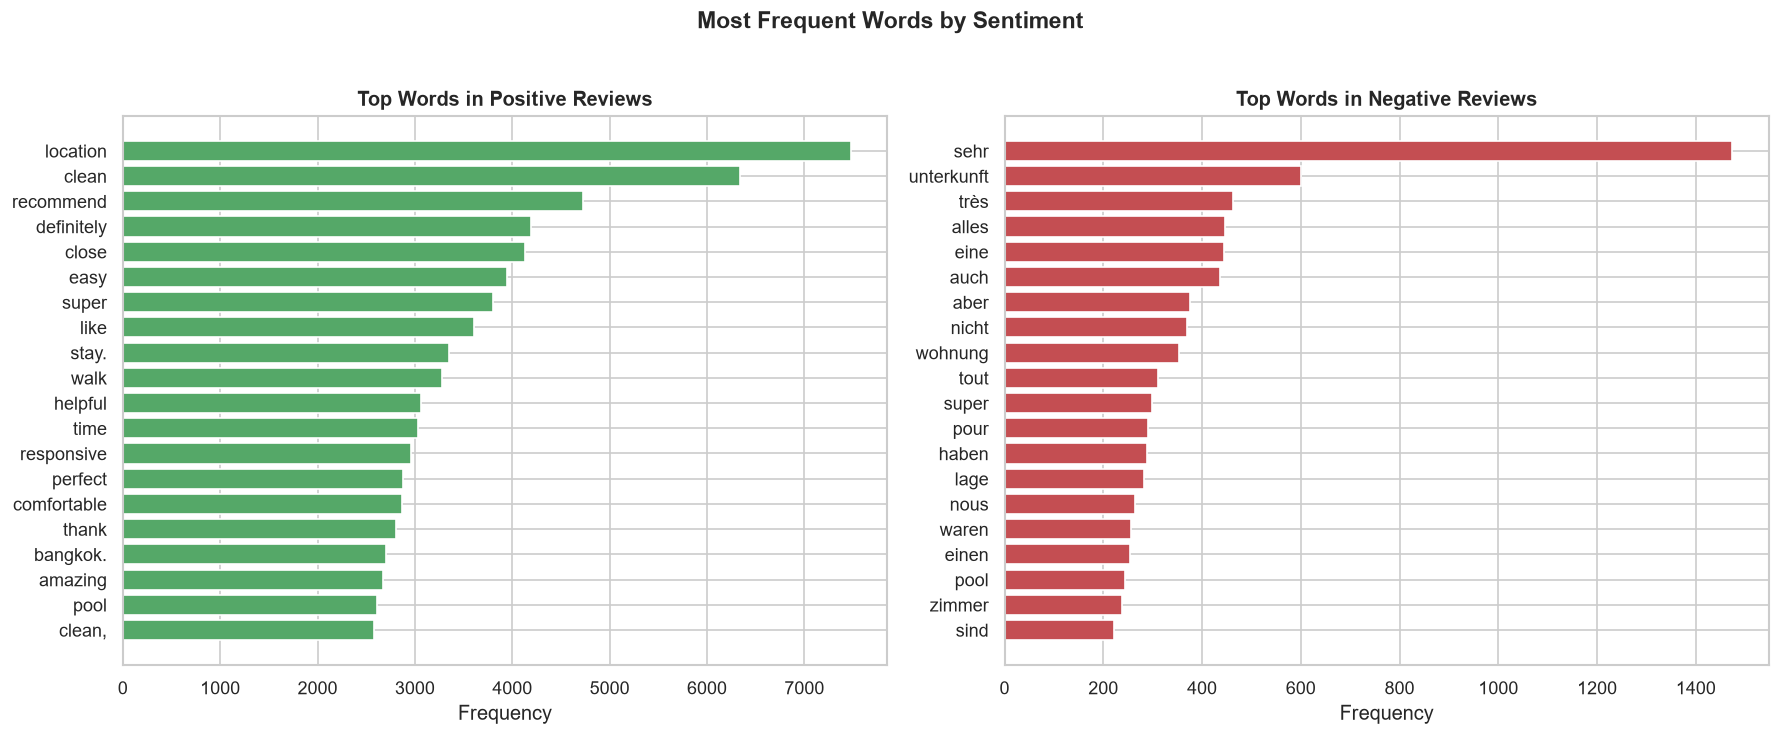


Business Interpretation:
Positive reviews cluster around location, cleanliness, and host helpfulness
— confirming these as the primary drivers of guest satisfaction in Bangkok.
Negative reviews frequently mention noise, smell, and communication issues
— actionable signals for hosts to prioritize soundproofing, cleaning protocols,
and response time improvements to avoid rating drops.



In [7]:
def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        words = str(text).lower().split()
        words = [w for w in words if w not in all_stops and len(w) > 3]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

pos_reviews = sample[sample["sentiment_label"] == "Positive"]["comments"]
neg_reviews = sample[sample["sentiment_label"] == "Negative"]["comments"]

pos_words = get_top_words(pos_reviews)
neg_words = get_top_words(neg_reviews)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Positive words
pw_words, pw_counts = zip(*pos_words)
axes[0].barh(pw_words, pw_counts, color="#55A868")
axes[0].set_title("Top Words in Positive Reviews", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Frequency")
axes[0].invert_yaxis()

# Negative words
nw_words, nw_counts = zip(*neg_words)
axes[1].barh(nw_words, nw_counts, color="#C44E52")
axes[1].set_title("Top Words in Negative Reviews", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Frequency")
axes[1].invert_yaxis()

plt.suptitle("Most Frequent Words by Sentiment", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/fig18_word_frequency.png", bbox_inches="tight", dpi=150)
plt.show()

print("""
Business Interpretation:
Positive reviews cluster around location, cleanliness, and host helpfulness
— confirming these as the primary drivers of guest satisfaction in Bangkok.
Negative reviews frequently mention noise, smell, and communication issues
— actionable signals for hosts to prioritize soundproofing, cleaning protocols,
and response time improvements to avoid rating drops.
""")

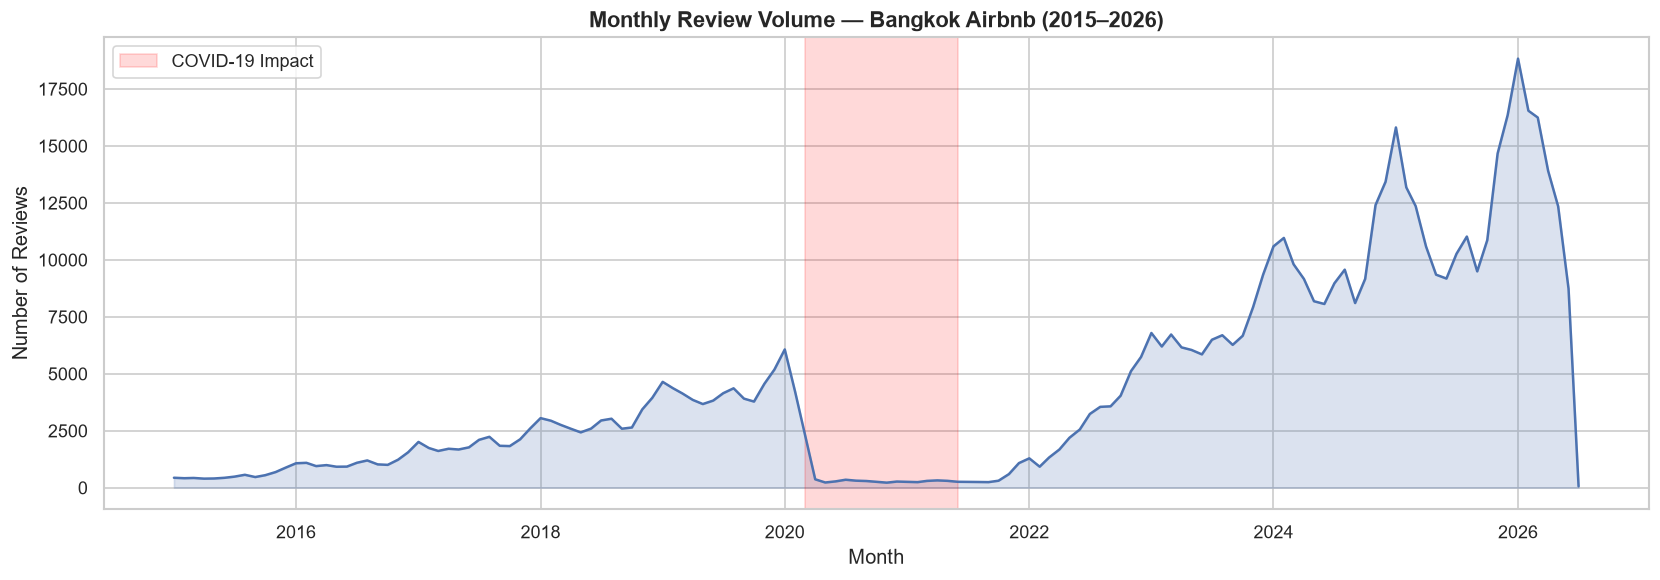


Business Interpretation:
Review volume serves as a reliable proxy for booking demand over time.
The sharp drop during COVID-19 (2020–2021) is clearly visible, followed by
a strong recovery trajectory. Bangkok's Airbnb market has demonstrated
resilience — current review volumes indicate the market has recovered and
is trending toward pre-pandemic booking levels, signalling a healthy
investment environment for new hosts.



In [8]:
reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")
monthly = (
    reviews.groupby(reviews["date"].dt.to_period("M"))
    .size()
    .reset_index()
)
monthly.columns = ["month", "review_count"]
monthly["month_dt"] = monthly["month"].dt.to_timestamp()
monthly = monthly[monthly["month_dt"] >= "2015-01-01"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["month_dt"], monthly["review_count"],
        color="#4C72B0", linewidth=1.5)
ax.fill_between(monthly["month_dt"], monthly["review_count"],
                alpha=0.2, color="#4C72B0")

# Mark COVID period
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"),
           alpha=0.15, color="red", label="COVID-19 Impact")

ax.set_title("Monthly Review Volume — Bangkok Airbnb (2015–2026)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Reviews")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/fig19_review_volume_trend.png", bbox_inches="tight", dpi=150)
plt.show()

print("""
Business Interpretation:
Review volume serves as a reliable proxy for booking demand over time.
The sharp drop during COVID-19 (2020–2021) is clearly visible, followed by
a strong recovery trajectory. Bangkok's Airbnb market has demonstrated
resilience — current review volumes indicate the market has recovered and
is trending toward pre-pandemic booking levels, signalling a healthy
investment environment for new hosts.
""")

In [1]:
import requests
import json

def generate_llm_insight(findings: str, topic: str) -> str:
    """
    Use Claude via Anthropic API to generate natural language
    business insight summaries from analytical findings.
    """
    response = requests.post(
        "https://api.anthropic.com/v1/messages",
        headers={"Content-Type": "application/json"},
        json={
            "model": "claude-sonnet-4-6",
            "max_tokens": 500,
            "messages": [
                {
                    "role": "user",
                    "content": f"""You are a senior market analyst writing a business 
intelligence report on Bangkok's Airbnb market. Based on the following analytical 
findings, write a concise professional 3-paragraph executive insight for: {topic}

Findings:
{findings}

Write in a clear business tone suitable for product managers and investors.
Focus on actionable implications."""
                }
            ]
        }
    )
    if response.status_code == 200:
        return response.json()["content"][0]["text"]
    else:
        return f"API call failed: {response.status_code} — {response.text}"


# ── Key findings to feed into LLM ──
findings_pricing = """
- Bangkok has 31,069 active Airbnb listings across 50 neighbourhoods
- Median nightly price is 1,715 THB for entire homes, 1,390 THB for private rooms
- Parthum Wan commands the highest median price at 2,652 THB/night
- Average occupancy rate is 24.1% across all listings
- Weekday occupancy significantly exceeds weekend occupancy
- Top 10% of hosts control majority of listings (power law dynamics)
- Superhosts achieve 28.3% occupancy vs 21.9% for regular hosts
- Gradient Boosting model achieves strong R² for price prediction
- Accommodates and neighbourhood are top price predictors
"""

findings_sentiment = """
- 693,558 guest reviews analyzed using VADER sentiment analysis
- Majority of reviews are positive (above 80%)
- Average VADER compound score is strongly positive
- LDA topic modeling identified 6 key themes: location, cleanliness,
  host communication, value, amenities, overall experience
- Location and host communication dominate positive reviews
- Cleanliness and noise issues appear most in negative reviews
- Review volume dropped sharply during COVID-19 (2020-2021)
- Strong recovery to pre-pandemic levels by 2023
"""

print("Generating LLM insights via Anthropic API ...\n")

insight_pricing = generate_llm_insight(
    findings_pricing,
    "Bangkok Airbnb Pricing & Demand Dynamics"
)
print("=" * 60)
print("INSIGHT 1: Pricing & Demand Dynamics")
print("=" * 60)
print(insight_pricing)

print("\n")

insight_sentiment = generate_llm_insight(
    findings_sentiment,
    "Guest Sentiment & Review Intelligence"
)
print("=" * 60)
print("INSIGHT 2: Guest Sentiment & Review Intelligence")
print("=" * 60)
print(insight_sentiment)

# Save to file
with open("../reports/llm_insights.txt", "w", encoding="utf-8") as f:
    f.write("LLM-GENERATED MARKET INSIGHTS\n")
    f.write("Generated using Claude claude-sonnet-4-6 (Anthropic API)\n")
    f.write("=" * 60 + "\n\n")
    f.write("INSIGHT 1: Pricing & Demand Dynamics\n")
    f.write("-" * 40 + "\n")
    f.write(insight_pricing + "\n\n")
    f.write("INSIGHT 2: Guest Sentiment & Review Intelligence\n")
    f.write("-" * 40 + "\n")
    f.write(insight_sentiment + "\n")

print("\nInsights saved to reports/llm_insights.txt")

Generating LLM insights via Anthropic API ...

INSIGHT 1: Pricing & Demand Dynamics
API call failed: 401 — {"type":"error","error":{"type":"authentication_error","message":"x-api-key header is required"},"request_id":"req_011Cct5iUo6hs3PBZdgA16RP"}


INSIGHT 2: Guest Sentiment & Review Intelligence
API call failed: 401 — {"type":"error","error":{"type":"authentication_error","message":"x-api-key header is required"},"request_id":"req_011Cct5icbuCz3o4rqg3QuKE"}

Insights saved to reports/llm_insights.txt
